# Polar plot
Based on https://github.com/climberlenny/test_openberg/blob/main/toolbox/postprocessing.py

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [2]:
from src.utils import *
from openberg_july2026.src2.utils0 import *
from openberg_july2026.src2.utils2 import *
from openberg_july2026.src2.utils3 import *
import glob

In [3]:
# Read and subset tracker data
ib = 'iceberg2024e'
#read obs
fname = 'merged_obs10'#'merged_obs_iceberg2026e_3D'
with xr.open_dataset('./input/%s.nc'%fname) as ds:
    obs = ds.sel(iceberg=ib,trajectory_id=ib) 
    obs_seed = obs.isel(time=(obs.seed_idx==1))

In [45]:
#read sim
file_contain_all = [ib,]
file_contain_any = ['_']
file_notcontain = ['test','idx','main','prof',]#'test','wa','next','glorys']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/%s/*.nc"%ib)#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l#[::-1]
print(file_l)

['./results/iceberg2024e/iceberg2024e_gebco_glorys_windglophynrt_joined.nc', './results/iceberg2024e/iceberg2024e_gebco_glophyanfcH_glophyanfcD_windglophynrt_joined.nc', './results/iceberg2024e/iceberg2024e_gebco_topaz5_windglophynrt_joined.nc', './results/iceberg2024e/iceberg2024e_gebco_topaz4_windglophynrt_joined.nc', './results/iceberg2024e/iceberg2024e_gebco_topaz6_topaz5_windglophynrt_joined.nc']


In [46]:
#dicts and definitions
legenddict = dict.fromkeys([f.split('/')[-1][:-3] for f in file_l])
for f in legenddict:
    ll = []
    for l in legenddict_full:
        if (l!='ICEBERG') and (l.lower() in f.lower()): ll = ll+[l]  
    legenddict[f]={'col':legenddict_full[ll[-1]]['col'], 'alpha':1, 'kw':', '.join(ll),'zo':legenddict_full[ll[-1]]['zo'],
                 'traj':np.arange(obs.time.size*11)}
#manual adaptions
# legenddict['iceberg2018b_gebco_topaz4_windglophyre']['zo']=25

legenddict 

{'iceberg2024e_gebco_glorys_windglophynrt_joined': {'col': 'darkolivegreen',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, GLORYS',
  'zo': 20,
  'traj': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
          13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
          26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
          39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
          52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
          65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
          78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
          91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
         104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
         117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
         130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
         143, 144, 145, 146, 147, 148, 149

In [47]:
try: #if not joined
    simall = xr.open_mfdataset(file_l,concat_dim="run",combine="nested")
    simall = simall.assign_coords(run=list(legenddict.keys()))
except:     #if joined already
    simall = xr.open_mfdataset(file_l) 
    #then adjust legenddict as well
    legenddict = dict.fromkeys([str(f) for f in simall.run.values])
    for f in legenddict:
        ll = []
        for l in legenddict_full:
            if l.lower() in f: ll = ll+[l]
        legenddict[f]={'col':legenddict_full[ll[-1]]['col'], 'alpha':1, 'kw':', '.join(ll),'zo':legenddict_full[ll[-1]]['zo'],
                     'traj':np.arange(obs.time.size*11)}

In [56]:
# --- Subset---
apn = dict_analysis_period[ib]['full']

# ---Trajectory subset
sim = simall
if ib in dict_traj.keys():
    for run in list(sim.run.values):
        if run in dict_traj[ib]: 
            sim = sim.sel(trajectory=dict_traj[ib][run])
            print('Trajectory subset applied on ',run)

# ---Time subset
if apn!=None: 
    sim = sim.sel(time=apn)
    print('Time subset applied: ',apn)

# ---time frequnecy subset
days = obs.time.dt.floor("D")
days2 = np.arange(obs_seed.time.dt.floor("D")[0].values,
                  obs_seed.time.dt.floor("D")[-1].values+np.timedelta64(str(obs.seed_freq.values)[:-1],str(obs.seed_freq.values)[-1]),
                  dtype='datetime64[D]')
idx = [
    np.where(days == np.datetime64(d))[0][0]
    for d in days2
    if (days == np.datetime64(d)).any()
]
obs_subtime = obs.isel(time=idx)
sim_obssubtime = sim.sel(time=obs_subtime.time, method="nearest") 

sim_sub = sim_obssubtime
obs_sub = obs_subtime

Time subset applied:  slice('2024-07-06', '2024-08-22', None)


iceberg2024e_gebco_glorys_windglophynrt_joined 0 109 0 109 darkolivegreen
iceberg2024e_gebco_glophyanfcH_glophyanfcD_windglophynrt_joined 0 109 0 109 darkseagreen
iceberg2024e_gebco_topaz5_windglophynrt_joined 0 109 0 109 cornflowerblue
iceberg2024e_gebco_topaz4_windglophynrt_joined 0 109 0 109 darkslateblue
iceberg2024e_gebco_topaz6_topaz5_windglophynrt_joined 0 109 0 109 turquoise


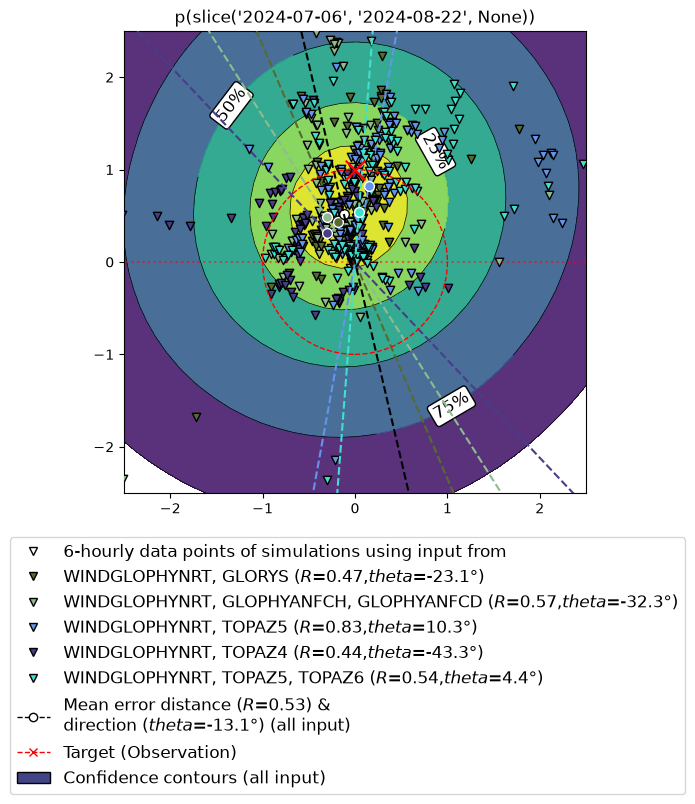

In [57]:
# del polarplot_m
# from openberg_july2026.src2.utils3 import polarplot_m
out = polarplot_m(sim_sub,obs_sub,legenddict,title='p(%s)'%apn)

In [58]:
#means
[{k:(float(v[0]),int(np.round(v[1])))} for k,v in out['mean'].items() if k != 'all']

[{'iceberg2024e_gebco_glorys_windglophynrt_joined': (0.47, -23)},
 {'iceberg2024e_gebco_glophyanfcH_glophyanfcD_windglophynrt_joined': (0.57,
   -32)},
 {'iceberg2024e_gebco_topaz5_windglophynrt_joined': (0.83, 10)},
 {'iceberg2024e_gebco_topaz4_windglophynrt_joined': (0.44, -43)},
 {'iceberg2024e_gebco_topaz6_topaz5_windglophynrt_joined': (0.54, 4)}]

In [59]:
#spreads
[{k:(float(v[1]),int(np.round(v[-1])))} for k,v in out['spread'].items() if k != 'all']

[{'iceberg2024e_gebco_glorys_windglophynrt_joined': (2.04, 155)},
 {'iceberg2024e_gebco_glophyanfcH_glophyanfcD_windglophynrt_joined': (2.81,
   157)},
 {'iceberg2024e_gebco_topaz5_windglophynrt_joined': (1.89, 128)},
 {'iceberg2024e_gebco_topaz4_windglophynrt_joined': (1.1, 146)},
 {'iceberg2024e_gebco_topaz6_topaz5_windglophynrt_joined': (2.85, 167)}]

In [37]:
out

{'mean': {'all': [np.float64(0.54), np.float64(-17.72)],
  'iceberg2024e_gebco_glorys_windglophynrt_joined': [np.float64(0.47),
   np.float64(-23.09)],
  'iceberg2024e_gebco_glophyanfcH_glophyanfcD_windglophynrt_joined': [np.float64(0.57),
   np.float64(-32.34)],
  'iceberg2024e_gebco_topaz5_windglophynrt_joined': [np.float64(0.83),
   np.float64(10.3)],
  'iceberg2024e_gebco_topaz4_windglophynrt_joined': [np.float64(0.44),
   np.float64(-43.34)]},
 'spread': {'all': [np.float64(7.74),
   np.float64(2.08),
   np.float64(351.97),
   np.float64(163.05)],
  'iceberg2024e_gebco_glorys_windglophynrt_joined': [np.float64(7.11),
   np.float64(2.04),
   np.float64(341.89),
   np.float64(155.38)],
  'iceberg2024e_gebco_glophyanfcH_glophyanfcD_windglophynrt_joined': [np.float64(6.67),
   np.float64(2.81),
   np.float64(348.78),
   np.float64(156.85)],
  'iceberg2024e_gebco_topaz5_windglophynrt_joined': [np.float64(4.48),
   np.float64(1.89),
   np.float64(325.54),
   np.float64(128.27)],
  'iceb